In [1]:
import os
import sys

os.chdir("..")  # Go up one directory
sys.path.append("src/")

import datetime
import gc
import time
from collections import defaultdict
from pathlib import Path
from pprint import pprint

import einops
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from tqdm import tqdm

import wandb
from config import Config
from model import CASunGroup
from viz import (
    capture_snapshot,
    create_video,
    generate_nca_colors,
    get_shannon_entropy,
)
from world import World


In [2]:
def store_video(raw_frames, name="output", pixel_size=2):
    frames = []
    for raw_frame in raw_frames:
        frames.append(capture_snapshot(raw_frame, nca_colors))

    upscaled_frames = []
    for frame in frames:
        # Upscale each pixel
        upscaled_frame = einops.repeat(
            frame,
            "c h w -> c (h repeat_h) (w repeat_w)",
            repeat_h=pixel_size,
            repeat_w=pixel_size,
        )
        upscaled_frames.append(upscaled_frame)

    del frames
    gc.collect()

    video_frames = einops.rearrange(
        (torch.stack(upscaled_frames) * 255).to(torch.uint8), "n c h w -> n h w c"
    )  # [N,C,H,W]
    create_video(video_frames, output_path=f"{name}.mp4", fps=30)

In [3]:
def get_agent_hidden(grid: torch.Tensor, nca_idx: int, config: Config) -> torch.Tensor:
    """Extract one agent's hidden channels from the current grid layout."""
    h_slice = config.agent_h_slice(nca_idx)
    return grid[h_slice]


def extract_nca_hidden_territory(
    grid: torch.Tensor, nca_idx: int, config: Config
) -> torch.Tensor:
    """Return an agent's hidden channels restricted to cells it occupies."""
    aliveness = grid[nca_idx + 1]
    mask = aliveness > 0.1
    hidden = get_agent_hidden(grid, nca_idx, config).clone()
    return hidden[:, mask]


def track_stats(steps_taken, data, grid, group, config, stats=None, save_grid=False):
    """Track territory, hidden-state entropy, and current competitive diagnostics."""
    grid = grid.detach()
    nca_stats = {}

    for nca_i in range(config.n_ncas):
        alive_cells = int((grid[nca_i + 1] > 0.1).sum().item())
        territory = extract_nca_hidden_territory(grid, nca_i, config)

        if alive_cells > 0 and territory.numel() > 0:
            entropy = float(get_shannon_entropy(territory).mean())
        else:
            entropy = 0.0

        nca_stats[f"nca_{nca_i}"] = {
            "alive_cells": alive_cells,
            "shannon_entropy": entropy,
            "grad_norm": float(stats.get("grad_norm", 0.0)) if stats else 0.0,
            "reconstruction_mse": float(stats.get("reconstruction_mse", [0.0] * config.n_ncas)[nca_i]) if stats else 0.0,
        }

    data["nca_stats"].append(nca_stats)
    data["global_stats"].append(stats if stats else None)
    data["timesteps"].append(steps_taken)

    if save_grid:
        data["grids"].append(grid.clone().cpu())


In [4]:
# ------------ SETTINGS ------------

SETTINGS = {
    "load_method": "file",  # Either file / wandb
    "total_steps": 1_000_000,
    "plot_every": 5,
}

# ----------------------------------

assert SETTINGS["load_method"] == "wandb" or SETTINGS["load_method"] == "file"

In [5]:
config = None
loaded_run_dir = None

if SETTINGS["load_method"] == "file":
    # ---------- FILE PATH TO EDIT ------------
    file_path = "configs/tiny-config.json"
    # file_path = "2025-10-30_15-28-46/config.json"
    # -----------------------------------------

    config_path = Path(file_path)
    config = Config.from_file(str(config_path))

    if config_path.name == "config.json" and config_path.parent.exists():
        loaded_run_dir = config_path.parent
elif SETTINGS["load_method"] == "wandb":
    # ---------- WANDB THINGS TO EDIT ------------
    entity = "[USERNAME]"
    project = "[PROJECT]"
    run_id = "[RUN_ID]"
    # --------------------------------------------

    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")

    run_config = run.config

    config = Config()

    for k, v in run_config.items():
        if "-" in k:
            continue
        setattr(config, k, v)
else:
    raise Exception("Invalid loading method")


In [6]:
# ------------- MANUAL EDITS HERE -------------

config.grid_size = [128, 128]
config.n_seeds = 4
config.batch_size = 1
config.pool_size = 1
config.seed = 13

# For quick notebook testing, these are usually helpful:
# config.steps_per_update = 4
# config.log_every = 1
# config.region_bins = 8

# ---------------------------------------------

config.__post_init__()
pprint(config)


Config(grid_size=[128, 128],
       n_seeds=4,
       cell_hidden_dim=8,
       alive_visible=True,
       alive_threshold=0.4,
       env_kind='sine',
       env_dim=4,
       sine_x_min=-3.141592653589793,
       sine_x_max=3.141592653589793,
       data_assignment='x_axis',
       data_x_values=None,
       data_y_values=None,
       data_env_vectors=None,
       seed_dist='scatter',
       seed_mode='random',
       burn_in=False,
       burn_in_increment_epochs=0,
       burn_in_increment=0,
       n_ncas=4,
       n_hidden_layers=1,
       hidden_dim=32,
       latent_dim=4,
       decoder_hidden_dim=16,
       model_kernel_size=3,
       model_dropout_per=0.0,
       softmax_temp=1.0,
       reconstruction_loss_scale=1.0,
       optimizer='Adam',
       learning_rate=0.0003,
       batch_size=1,
       pool_size=1,
       epochs=200,
       log_every=20,
       wandb=False,
       steps_before_update=0,
       steps_per_update=4,
       region_bins=8,
       device='cpu',
      

In [7]:
# Step 3: Run
nca_colors = generate_nca_colors(config.n_ncas)

group = CASunGroup(config)
world = World(config)

if loaded_run_dir is not None and (loaded_run_dir / "model.pt").exists():
    group.load(str(loaded_run_dir))
    print(f"> loaded model from {loaded_run_dir}")

grid, env = world.get_seed()

steps_taken = 0
vids_saved = 0
steps_to_add = config.steps_before_update + config.steps_per_update

timestep_data = {
    "grids": [],
    "nca_stats": [],
    "global_stats": [],
    "timesteps": [],
}

experiment_id = datetime.datetime.fromtimestamp(time.time()).strftime(
    "%Y-%m-%d %H:%M:%S"
)
experiment_dir = f"logs/{experiment_id}"
os.makedirs(experiment_dir, exist_ok=True)

config.save(f"{experiment_dir}/config.json")

pbar = tqdm(total=SETTINGS["total_steps"])

print(f"> starting experiment {experiment_id}")


  0%|          | 0/1000000 [00:00<?, ?it/s]

> starting experiment 2026-04-22 13:53:55


In [8]:
# Grid dimensions
aspect_ratio = config.grid_size[0] / config.grid_size[1]  # 16:1

# Set figure width and calculate height
fig_width = 12  # inches
fig_height = fig_width / aspect_ratio  # 1 inch

dpi_display = 100
dpi_save = 300

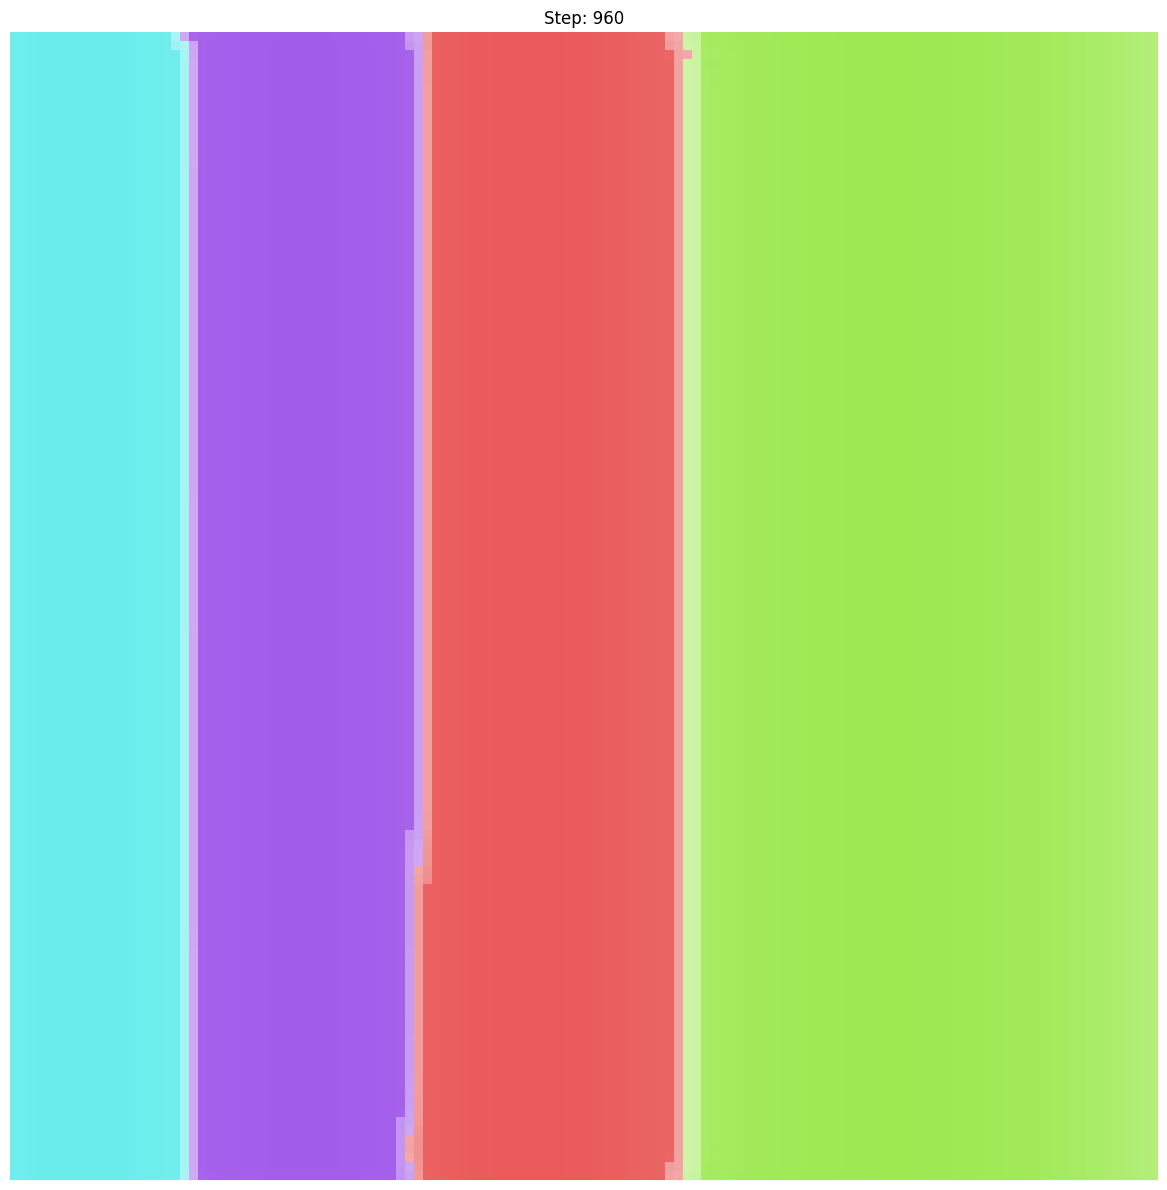

  0%|          | 968/1000000 [02:50<34:29:32,  8.05it/s]

In [ ]:
while steps_taken < SETTINGS["total_steps"]:
    if steps_taken % SETTINGS["plot_every"] == 0:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi_display)
        ax.imshow(capture_snapshot(grid, nca_colors).permute(1, 2, 0))
        ax.set_title(f"Step: {steps_taken}")
        ax.axis("off")
        plt.tight_layout()

        plt.savefig(
            f"{experiment_dir}/{steps_taken:08d}", dpi=dpi_save, bbox_inches="tight"
        )

        display(fig)
        plt.close(fig)
        display(pbar)

    stats, grid, grids = world.step(group, grid, env)

    for i in range(len(grids)):
        track_stats(
            steps_taken + i, timestep_data, grids[i, 0], group, config, stats, save_grid=True
        )

    steps_taken += steps_to_add
    pbar.update(steps_to_add)

pbar.close()


## Analysis

This notebook is patched for the autoencoder-competition version.

What the plots below now track:
- territory over time
- per-agent hidden-state entropy over time
- simple correlations between territory and hidden-state entropy

Notes:
- attack/defense channel analysis from the original notebook is no longer applicable
- the current grid stores alive channels plus per-agent hidden channels
- environment embeddings and latent/reconstruction competition are computed outside the persistent grid state


In [ ]:
def show_nca_colors(colors):
    """Display a minimal color legend for NCAs."""
    fig, ax = plt.subplots(figsize=(12, 0.4), dpi=dpi_display)
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor="none"))
    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    ax.set_xticks([i + 0.5 for i in range(len(colors))])
    ax.set_xticklabels([f"NCA {i}" for i in range(len(colors))], fontsize=8)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    # plt.tight_layout()
    plt.show()


show_nca_colors(nca_colors)

In [ ]:
xs_idxs = np.arange(len(timestep_data["nca_stats"]))
xs = timestep_data["timesteps"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlabel("Timestep")
ax.set_ylabel("Population")

for nca_i in range(config.n_ncas):
    territories = []

    for step in range(len(timestep_data["nca_stats"])):
        stats = timestep_data["nca_stats"][step]
        if f"nca_{nca_i}" in stats:
            territories.append(stats[f"nca_{nca_i}"]["alive_cells"])
        else:
            territories.append(0)

    color = nca_colors[nca_i][:3] if nca_i < len(nca_colors) else plt.cm.tab10(nca_i)

    ax.plot(xs_idxs, territories, color=color, linewidth=1, alpha=0.8)

plt.title("Territory size")
plt.tight_layout()

n_ticks = 10  # Number of ticks you want to show
tick_indices = np.linspace(0, len(xs_idxs) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_indices)
ax.set_xticklabels([xs[i] for i in tick_indices])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{experiment_dir}/territory_{steps_taken}", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
xs_idxs = np.arange(len(timestep_data["nca_stats"]))
xs = timestep_data["timesteps"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlabel("Timestep")
ax.set_ylabel("Avg. Bits Encoded/Hidden Channel")

for nca_i in range(config.n_ncas):
    ents = []

    for step in range(len(timestep_data["nca_stats"])):
        stats = timestep_data["nca_stats"][step]
        if f"nca_{nca_i}" in stats:
            ents.append(stats[f"nca_{nca_i}"]["shannon_entropy"])
        else:
            ents.append(0)

    color = nca_colors[nca_i][:3] if nca_i < len(nca_colors) else plt.cm.tab10(nca_i)
    ax.plot(xs_idxs, ents, "--", color=color, linewidth=1, alpha=0.8)

plt.title("Hidden-state information")
plt.tight_layout()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

n_ticks = 10
tick_indices = np.linspace(0, len(xs_idxs) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_indices)
ax.set_xticklabels([xs[i] for i in tick_indices])

plt.savefig(f"{experiment_dir}/hidden_entropy_{steps_taken}", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
## Q: Is there any relationship between hidden-state entropy and population?

corrs = []

for nca_i in range(config.n_ncas):
    territories = []
    ents = []

    for step in range(len(timestep_data["nca_stats"])):
        stats = timestep_data["nca_stats"][step]
        if f"nca_{nca_i}" in stats:
            territories.append(stats[f"nca_{nca_i}"]["alive_cells"])
            ents.append(stats[f"nca_{nca_i}"]["shannon_entropy"])
        else:
            territories.append(0)
            ents.append(0)

    territories = np.array(territories)
    ents = np.array(ents)

    if len(territories) > 1 and territories.std() > 0 and ents.std() > 0:
        t_delta = territories[1:] - territories[:-1]
        e_delta = ents[1:] - ents[:-1]
        corr = np.corrcoef(territories, ents)[0, 1]
        corr_delta = np.corrcoef(t_delta, e_delta)[0, 1] if t_delta.std() > 0 and e_delta.std() > 0 else np.nan
        corrs.append(corr)
        print(f"NCA {nca_i} base corr. {corr * 100:.2f}% | delta corr. {corr_delta * 100:.2f}%")
    else:
        print(f"NCA {nca_i} corr undefined (insufficient variance)")


In [ ]:
## Q: Fewer surviving NCAs = less hidden-state information?

n_alive = [
    sum(1 for v in ts.values() if v["alive_cells"] > 0)
    for ts in timestep_data["nca_stats"]
]

bits_encoded = [
    np.mean([v["shannon_entropy"] for v in ts.values() if v["alive_cells"] > 0])
    if any(v["alive_cells"] > 0 for v in ts.values()) else 0.0
    for ts in timestep_data["nca_stats"]
]

grouped_data = defaultdict(list)
for n, bits in zip(n_alive, bits_encoded):
    grouped_data[n].append(bits)

n_alive_unique = sorted(grouped_data.keys())
means = [np.mean(grouped_data[n]) for n in n_alive_unique]
stds = [np.std(grouped_data[n]) for n in n_alive_unique]

plt.figure(figsize=(10, 6))

for n, mean, std in zip(n_alive_unique, means, stds):
    color_idx = n - 1 if n > 0 else 0
    if color_idx < len(nca_colors):
        color = nca_colors[color_idx][:3]
    else:
        color = plt.cm.tab10(color_idx)

    plt.errorbar(
        n,
        mean,
        yerr=std,
        fmt="o",
        capsize=5,
        capthick=2,
        markersize=8,
        color=color,
        ecolor=color,
    )

plt.xlabel("NCAs alive")
plt.ylabel("Mean hidden-state bits/channel")
plt.title("Hidden-state information vs number of NCAs alive")
plt.grid(True, alpha=0.3)
plt.savefig(f"{experiment_dir}/n_vs_hidden_bits_{steps_taken}", dpi=300)
plt.show()
